# 📊 YouTube en LATAM y su relación con la felicidad

Este análisis explora tres preguntas:

1. ¿Cómo varía el uso de YouTube (usuarios totales y tasa de penetración) entre los países de Latinoamérica?
2. ¿Existe relación entre la penetración de YouTube y el puntaje de felicidad de un país (*Life Ladder*, del World Happiness Report)? ¿Es esa relación lineal, o se ajusta mejor con una curva? ¿Sigue siendo relevante una vez que se controla por el uso general de redes sociales?
3. ¿Qué países combinan alto potencial económico/social pero baja penetración de YouTube respecto al uso general de redes sociales? (Índice de Oportunidad Digital)

**Fuentes de datos:**
- [YouTube Users by Country 2025](https://www.kaggle.com/datasets/arpitsinghaiml/youtube-user-by-country-2025) (Kaggle)
- [World Happiness Report 2024](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated) (Kaggle)
- [Social Media Users by Country](https://www.kaggle.com/datasets/edissoniiguez/social-media-users) (Kaggle)

> Los CSV no se incluyen en este repositorio por su tamaño y licencia. Ver `data/README.md` para instrucciones de descarga.


## 1. Librerías y configuración

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")

# Rutas de datos locales (ver data/README.md para descargarlos)
PATH_YOUTUBE = "../data/youtube-users-by-country-2025.csv"
PATH_HAPPINESS = "../data/world-happiness-report-updated_2024.csv"
PATH_SOCIAL = "../data/usuarios-de-redes-sociales-por-pais-en-2026.csv"


> **Nota:** si `statsmodels` no está instalado, corré `%pip install statsmodels` en una celda,
> reiniciá el kernel, y volvé a correr desde el principio.

## 2. Uso de YouTube en países de Latinoamérica

Cargamos el dataset de usuarios de YouTube y filtramos únicamente los países de LATAM.

In [2]:
yt_df = pd.read_csv(PATH_YOUTUBE)

latam_countries = [
    "Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Costa Rica",
    "Dominican Republic", "Ecuador", "El Salvador", "Guatemala", "Honduras",
    "Mexico", "Nicaragua", "Panama", "Paraguay", "Peru", "Uruguay", "Venezuela",
]

latam_df = yt_df[yt_df["country"].isin(latam_countries)].copy()
latam_df.head()


,flagCode,country,YouTubeUsers_TotalUsers_Num_2024Feb,YouTubeUsers_Penetration_Pct_2024Feb,YouTubeUsersJuly2023,YouTubeUsersPenetrationJuly2023
2,BR,Brazil,144000000,76.6,142.0,72.9
4,MX,Mexico,83100000,77.5,81.8,71.1
19,AR,Argentina,31300000,77.1,31.8,77.6
20,CO,Colombia,30300000,76.7,30.7,64.2
33,PE,Peru,17600000,68.3,17.6,57.3


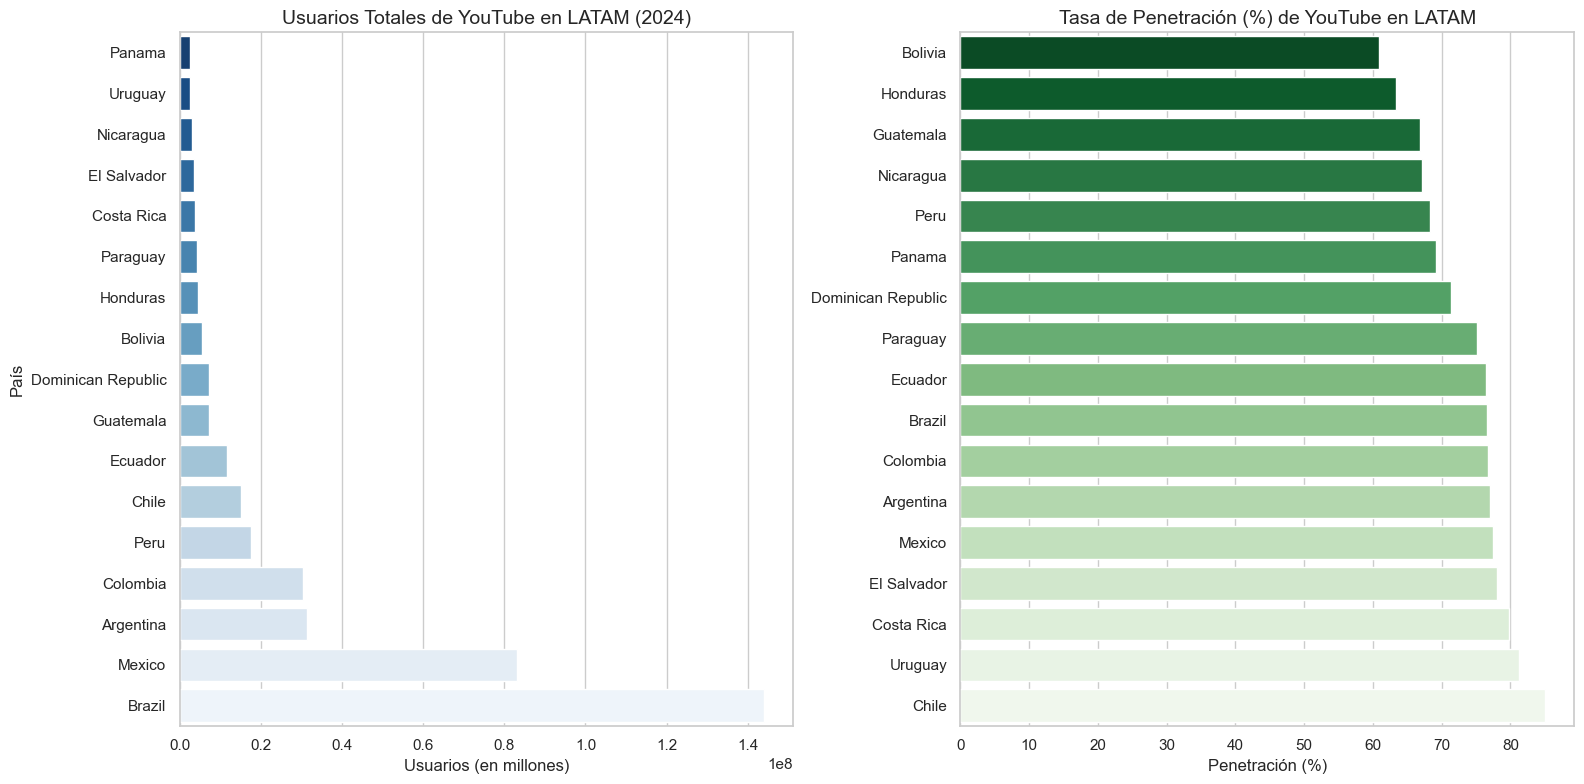

In [3]:
df_users = latam_df.sort_values(by="YouTubeUsers_TotalUsers_Num_2024Feb", ascending=True)
df_penetration = latam_df.sort_values(by="YouTubeUsers_Penetration_Pct_2024Feb", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    ax=axes[0], data=df_users,
    x="YouTubeUsers_TotalUsers_Num_2024Feb", y="country",
    palette="Blues_r", hue="country", legend=False,
)
axes[0].set_title("Usuarios Totales de YouTube en LATAM (2024)", fontsize=14)
axes[0].set_xlabel("Usuarios (en millones)")
axes[0].set_ylabel("País")

sns.barplot(
    ax=axes[1], data=df_penetration,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="country",
    palette="Greens_r", hue="country", legend=False,
)
axes[1].set_title("Tasa de Penetración (%) de YouTube en LATAM", fontsize=14)
axes[1].set_xlabel("Penetración (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/01_youtube_latam.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Penetración de YouTube vs. Felicidad (Life Ladder)

A partir de acá trabajamos con **todos los países disponibles** (no solo LATAM), para tener
suficientes observaciones al comparar YouTube, felicidad y redes sociales.

El World Happiness Report trae **una fila por país por año** (2005–2023). Si no filtramos por
año, cada país se cuenta varias veces y los resultados estadísticos quedan inflados de forma
artificial. Filtramos al año más reciente disponible antes de cualquier análisis.

In [4]:
whr_df = pd.read_csv(PATH_HAPPINESS, encoding="latin-1")
social_df = pd.read_csv(PATH_SOCIAL)

print("Filas totales en WHR (todos los años):", whr_df.shape[0])
print("Años disponibles:", sorted(whr_df["year"].unique()))

# Nos quedamos con el año más reciente para evitar duplicar países
whr_df = whr_df[whr_df["year"] == 2023].copy()

# Estandarización de nombres para el JOIN
whr_df["Country name"] = whr_df["Country name"].replace({
    "United States": "United States of America",
    "Czechia": "Czech Republic",
    "Taiwan Province of China": "Taiwan",
})

# Unimos las tres fuentes: YouTube + Felicidad + Redes sociales
merged_df = pd.merge(yt_df, whr_df, left_on="country", right_on="Country name", how="inner")
merged_df = pd.merge(merged_df, social_df, on="country", how="inner")

print("Países con datos completos en las 3 fuentes:", merged_df.shape[0])


Filas totales en WHR (todos los años): 2363
Años disponibles: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Países con datos completos en las 3 fuentes: 79


### 3.1 Correlación simple: YouTube vs. Felicidad

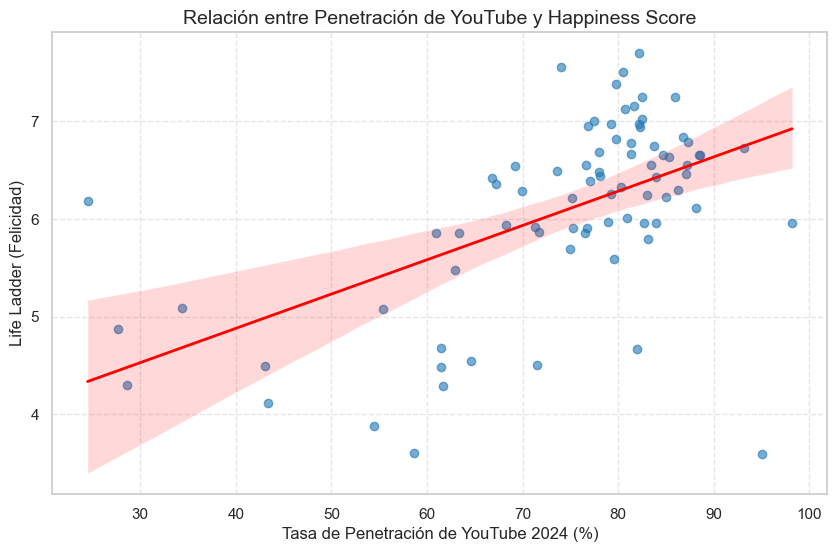

In [5]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=merged_df,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="Life Ladder",
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title("Relación entre Penetración de YouTube y Happiness Score", fontsize=14)
plt.xlabel("Tasa de Penetración de YouTube 2024 (%)", fontsize=12)
plt.ylabel("Life Ladder (Felicidad)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("../outputs/figures/02_penetracion_vs_felicidad.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
corr_pearson = merged_df["YouTubeUsers_Penetration_Pct_2024Feb"].corr(merged_df["Life Ladder"], method="pearson")
corr_spearman = merged_df["YouTubeUsers_Penetration_Pct_2024Feb"].corr(merged_df["Life Ladder"], method="spearman")

print(f"Coeficiente de Pearson:  {corr_pearson:.4f}")
print(f"Coeficiente de Spearman: {corr_spearman:.4f}")


Coeficiente de Pearson:  0.5456
Coeficiente de Spearman: 0.5210


**Lectura inicial:** una correlación de Pearson de ~0.5 sugiere una relación positiva moderada.
Pero esto **no confirma que la relación sea lineal ni causal** — es solo el punto de partida.
Las siguientes dos subsecciones ponen a prueba esa lectura inicial.

### 3.2 ¿La relación es realmente lineal?

Comparamos un ajuste lineal, cuadrático y cúbico sobre los mismos datos. Primero los gráficos,
para ver la forma de cada curva; después los números (R²), para cuantificar qué tan bien ajusta
cada una — y una nota de cautela sobre lo que ese número puede estar ocultando.

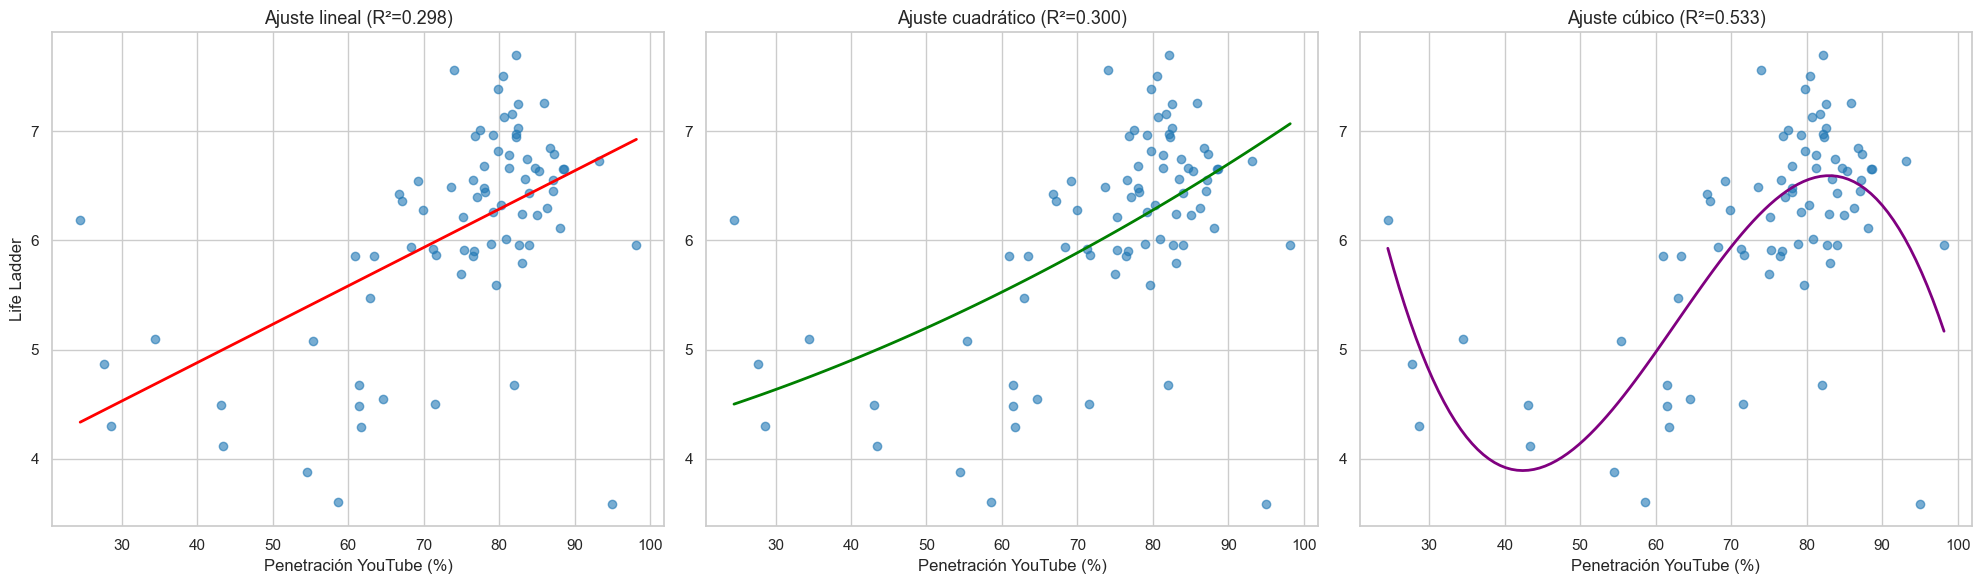

In [7]:
x = merged_df["YouTubeUsers_Penetration_Pct_2024Feb"].values
y = merged_df["Life Ladder"].values

coef_lineal = np.polyfit(x, y, 1)
coef_cuadratico = np.polyfit(x, y, 2)
coef_cubico = np.polyfit(x, y, 3)

r2_lineal = r2_score(y, np.polyval(coef_lineal, x))
r2_cuadratico = r2_score(y, np.polyval(coef_cuadratico, x))
r2_cubico = r2_score(y, np.polyval(coef_cubico, x))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.regplot(
    ax=axes[0], data=merged_df,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="Life Ladder",
    order=1, ci=None,
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
axes[0].set_title(f"Ajuste lineal (R²={r2_lineal:.3f})", fontsize=13)
axes[0].set_xlabel("Penetración YouTube (%)")
axes[0].set_ylabel("Life Ladder")

sns.regplot(
    ax=axes[1], data=merged_df,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="Life Ladder",
    order=2, ci=None,
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "green", "linewidth": 2},
)
axes[1].set_title(f"Ajuste cuadrático (R²={r2_cuadratico:.3f})", fontsize=13)
axes[1].set_xlabel("Penetración YouTube (%)")
axes[1].set_ylabel("")

sns.regplot(
    ax=axes[2], data=merged_df,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="Life Ladder",
    order=3, ci=None,
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "purple", "linewidth": 2},
)
axes[2].set_title(f"Ajuste cúbico (R²={r2_cubico:.3f})", fontsize=13)
axes[2].set_xlabel("Penetración YouTube (%)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/02b_lineal_vs_cuadratico_cubico.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
def r2_ajustado(r2, n, p):
    """R² ajustado: penaliza agregar parámetros que no aportan poder explicativo real."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n = len(merged_df)

print("             R²      R² ajustado")
print(f"Lineal:      {r2_lineal:.4f}   {r2_ajustado(r2_lineal, n, 1):.4f}")
print(f"Cuadrático:  {r2_cuadratico:.4f}   {r2_ajustado(r2_cuadratico, n, 2):.4f}")
print(f"Cúbico:      {r2_cubico:.4f}   {r2_ajustado(r2_cubico, n, 3):.4f}")

# Países en los extremos de X: si el salto del R² cúbico se explica por 1-2 países,
# deberían aparecer acá.
extremos = pd.concat([
    merged_df.nsmallest(3, "YouTubeUsers_Penetration_Pct_2024Feb")[["country", "YouTubeUsers_Penetration_Pct_2024Feb", "Life Ladder"]],
    merged_df.nlargest(3, "YouTubeUsers_Penetration_Pct_2024Feb")[["country", "YouTubeUsers_Penetration_Pct_2024Feb", "Life Ladder"]],
])
print("\nPaíses en los extremos de penetración de YouTube:")
print(extremos.to_string(index=False))


             R²      R² ajustado
Lineal:      0.2977   0.2885
Cuadrático:  0.3002   0.2818
Cúbico:      0.5332   0.5145

Países en los extremos de penetración de YouTube:
             country  YouTubeUsers_Penetration_Pct_2024Feb  Life Ladder
         Philippines                                  24.5        6.184
             Nigeria                                  27.7        4.869
               Ghana                                  28.6        4.298
             Bahrain                                  98.2        5.959
             Lebanon                                  95.0        3.588
United Arab Emirates                                  93.2        6.728


**Interpretación:** De manera simple se puede observar que no existe una relación lineal felicidad y el uso de Youtube en ese sentido el uso de varaibles cuadraticas y cubicas mejorar el R2 confirmando la relación no lineal.

### 3.3 ¿Es un efecto de YouTube, o de las redes sociales en general?

Comparamos la relación de YouTube con felicidad contra la relación de **uso general de redes
sociales** con felicidad, usando los mismos países.

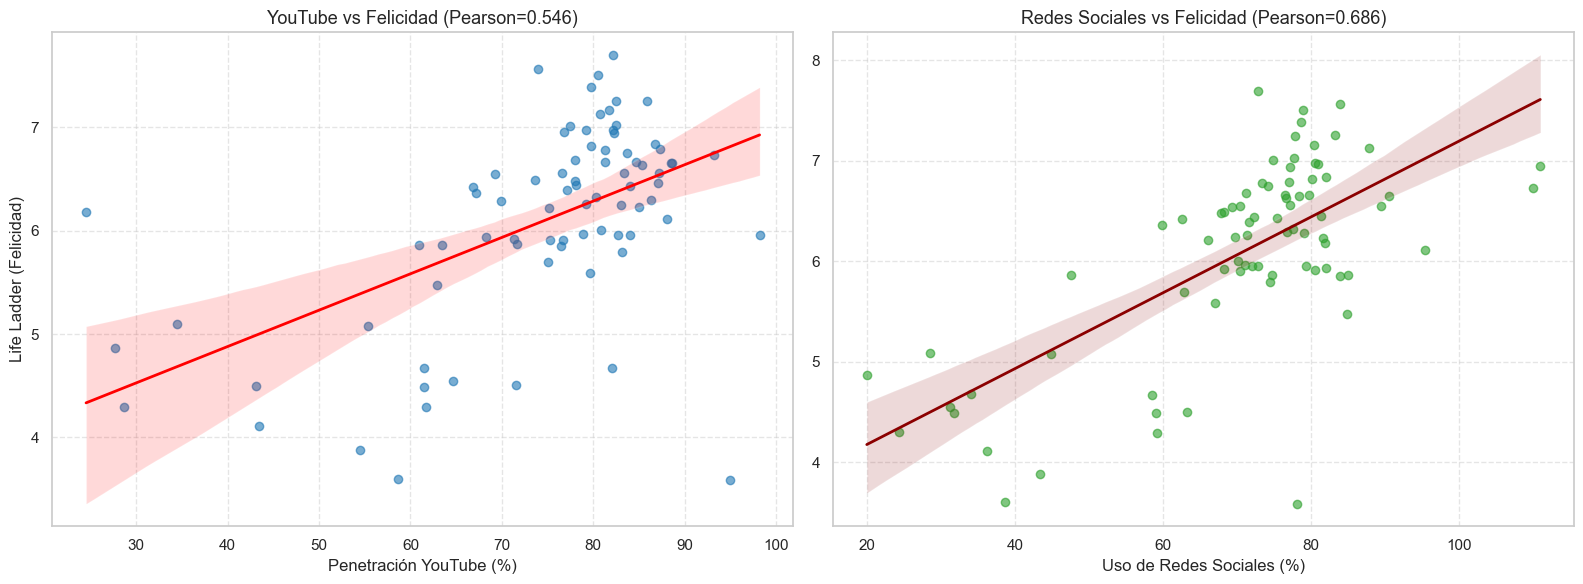

Pearson YouTube vs Felicidad:        0.5456
Pearson Redes Sociales vs Felicidad: 0.6864


In [9]:
corr_yt_pearson = merged_df["YouTubeUsers_Penetration_Pct_2024Feb"].corr(merged_df["Life Ladder"], method="pearson")
corr_social_pearson = merged_df["SocialMediaUsersPctOfPopulation_2025"].corr(merged_df["Life Ladder"], method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    ax=axes[0], data=merged_df,
    x="YouTubeUsers_Penetration_Pct_2024Feb", y="Life Ladder",
    order=1,
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
axes[0].set_title(f"YouTube vs Felicidad (Pearson={corr_yt_pearson:.3f})", fontsize=13)
axes[0].set_xlabel("Penetración YouTube (%)")
axes[0].set_ylabel("Life Ladder (Felicidad)")
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.regplot(
    ax=axes[1], data=merged_df,
    x="SocialMediaUsersPctOfPopulation_2025", y="Life Ladder",
    order=1,
    scatter_kws={"alpha": 0.6, "color": "#2ca02c"},
    line_kws={"color": "darkred", "linewidth": 2},
)
axes[1].set_title(f"Redes Sociales vs Felicidad (Pearson={corr_social_pearson:.3f})", fontsize=13)
axes[1].set_xlabel("Uso de Redes Sociales (%)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/03_youtube_vs_redes_felicidad.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson YouTube vs Felicidad:        {corr_yt_pearson:.4f}")
print(f"Pearson Redes Sociales vs Felicidad: {corr_social_pearson:.4f}")


El uso de redes sociales esta mas correlacionado con la felicidad que el uso de Youtube.

### 3.4 Modelo multivariado: ¿YouTube importa una vez que controlamos por redes sociales?

Los análisis anteriores miran cada variable por separado. Acá usamos regresión múltiple para ver
el efecto de la penetración de YouTube **manteniendo constante** el uso general de redes
sociales — esto separa el efecto propio de YouTube del efecto que podría estar "prestando" del
acceso a internet/redes en general.

In [10]:
X = merged_df[["YouTubeUsers_Penetration_Pct_2024Feb", "SocialMediaUsersPctOfPopulation_2025"]]
X = sm.add_constant(X)
y = merged_df["Life Ladder"]

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:            Life Ladder   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     34.60
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           2.07e-11
Time:                        15:13:44   Log-Likelihood:                -82.567
No. Observations:                  79   AIC:                             171.1
Df Residuals:                      76   BIC:                             178.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


**Cómo leer esto:** 
El uso de youtube no es significativo cuando e controla por el uso de redes sociales, lo que nos da entender que youtube no ejerce un efecto real en la felicidad una vez controlado otras plataformas dijitales mas utilizadas como son las redes sociales.

## 4. Índice de Oportunidad Digital

Combinamos las tres fuentes para construir un índice que resalta países con alto potencial
(buen PIB, buena felicidad, alto uso general de redes) pero que aún tienen una penetración de
YouTube relativamente baja — es decir, mercados con espacio para crecer.

In [12]:
df_advanced = merged_df.copy()

df_advanced["gap_youtube_vs_redes"] = (
    df_advanced["SocialMediaUsersPctOfPopulation_2025"]
    - df_advanced["YouTubeUsers_Penetration_Pct_2024Feb"]
)

cols_to_normalize = [
    "Life Ladder", "Log GDP per capita",
    "YouTubeUsers_Penetration_Pct_2024Feb", "gap_youtube_vs_redes",
]
df_advanced = df_advanced.dropna(subset=cols_to_normalize)

scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_advanced[cols_to_normalize])
df_advanced["felicidad_norm"] = normalized[:, 0]
df_advanced["GDP_norm"] = normalized[:, 1]
df_advanced["penetracion_norm"] = normalized[:, 2]
df_advanced["gap_norm"] = normalized[:, 3]

df_advanced["indice_oportunidad"] = (
    df_advanced["felicidad_norm"] + df_advanced["GDP_norm"] + df_advanced["gap_norm"]
) - df_advanced["penetracion_norm"]

top_10_potencial = df_advanced.sort_values(by="indice_oportunidad", ascending=False).head(10)
top_10_potencial[["country", "indice_oportunidad"]]


,country,indice_oportunidad
26,Philippines,1.890970
20,Saudi Arabia,1.609724
78,Iceland,1.558441
63,Ireland,1.406260
54,Denmark,1.347322
48,Switzerland,1.322037
67,Kuwait,1.297615
56,Norway,1.262228
37,United Arab Emirates,1.257928
58,Finland,1.232803


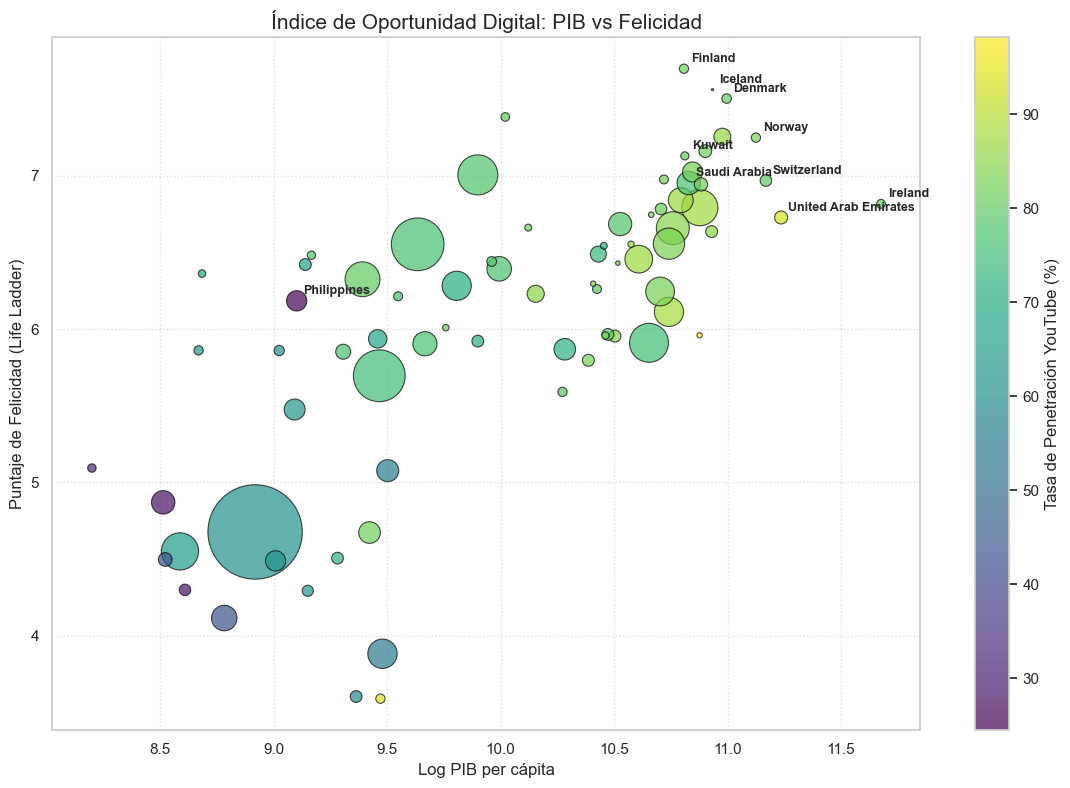

In [13]:
plt.figure(figsize=(14, 9))
scatter = plt.scatter(
    x=df_advanced["Log GDP per capita"],
    y=df_advanced["Life Ladder"],
    s=df_advanced["YouTubeUsers_TotalUsers_Num_2024Feb"] / 1e5,
    c=df_advanced["YouTubeUsers_Penetration_Pct_2024Feb"],
    cmap="viridis", alpha=0.7, edgecolors="black", linewidth=0.8,
)
cbar = plt.colorbar(scatter)
cbar.set_label("Tasa de Penetración YouTube (%)")

for _, row in top_10_potencial.iterrows():
    plt.annotate(
        row["country"],
        (row["Log GDP per capita"], row["Life Ladder"]),
        fontsize=9, fontweight="bold",
        xytext=(5, 5), textcoords="offset points",
    )

plt.title("Índice de Oportunidad Digital: PIB vs Felicidad", fontsize=15)
plt.xlabel("Log PIB per cápita", fontsize=12)
plt.ylabel("Puntaje de Felicidad (Life Ladder)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("../outputs/figures/04_indice_oportunidad_digital.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
print(top_10_potencial[[
    "country", "indice_oportunidad",
    "YouTubeUsers_TotalUsers_Num_2024Feb",
    "YouTubeUsers_Penetration_Pct_2024Feb",
    "SocialMediaUsersPctOfPopulation_2025",
    "gap_youtube_vs_redes",
    "Life Ladder",
]].to_string(index=False))


             country  indice_oportunidad  YouTubeUsers_TotalUsers_Num_2024Feb  YouTubeUsers_Penetration_Pct_2024Feb  SocialMediaUsersPctOfPopulation_2025  gap_youtube_vs_redes  Life Ladder
         Philippines            1.890970                             21350000                                  24.5                                  81.9                  57.4        6.184
        Saudi Arabia            1.609724                             28300000                                  76.8                                 111.0                  34.2        6.953
             Iceland            1.558441                               276000                                  74.0                                  83.9                   9.9        7.562
             Ireland            1.406260                              4010000                                  79.8                                  80.1                   0.3        6.817
             Denmark            1.347322               

## 5. Conclusiones

- La penetración de YouTube varía considerablemente dentro de LATAM, sin una relación directa
  con el tamaño poblacional de cada país.
- La correlación simple entre YouTube y felicidad es moderada (~0.5), pero al comparar ajustes
  lineal, cuadrático y cúbico, el salto de R² en el cúbico debe leerse con cautela: con pocas
  observaciones, los polinomios de mayor grado tienden a sobreajustar, especialmente si hay
  países en los extremos de la variable.
- En un modelo multivariado que controla por el uso general de redes sociales, la penetración
  de YouTube deja de ser estadísticamente significativa — el uso general de redes sociales
  explica la felicidad mejor que YouTube en particular. Esto sugiere que el efecto inicial
  observado con Pearson probablemente reflejaba el acceso a redes/internet en general, no algo
  específico de la plataforma.
- El Índice de Oportunidad Digital identifica países con alto potencial socioeconómico pero
  relativamente baja penetración de YouTube frente al uso general de redes sociales — posibles
  mercados con espacio de crecimiento para la plataforma.

**Próximos pasos posibles:** incorporar series temporales para ver evolución año a año, o
desagregar por franja etaria si el dataset lo permite.
